In [7]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# 1. Load dataset
data = fetch_california_housing()
X = data.data[:, [0]]  # Median Income feature
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Polynomial transformation
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 3. Train models
model = LinearRegression()
model.fit(X_train_poly, y_train)

# 4. Predict on test set
y_pred = model.predict(X_test_poly)

# 5. Metrics
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

print("w: ", model.coef_)
print("b: ", model.intercept_)

R² Score: 0.4671
w:  [ 0.          0.12090827  0.0654636  -0.00375478]
b:  0.7997781973783602


R² Score Linear Regression: 0.4671
R² Score Ridge Regression: 0.4671


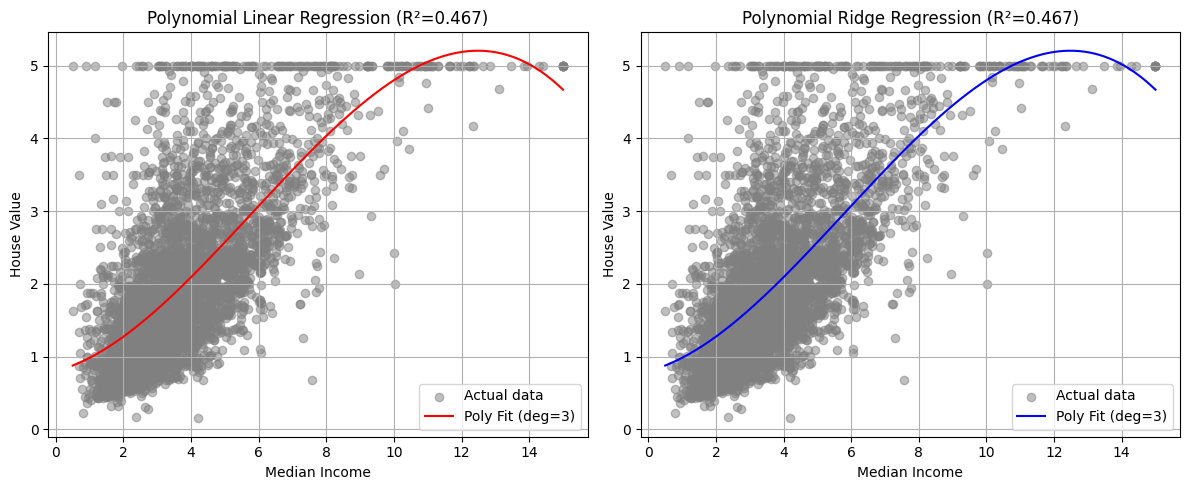

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load dataset
# -----------------------------
data = fetch_california_housing()
X = data.data[:, [0]]  # Median Income feature
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 2. Polynomial transformation
# -----------------------------
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# -----------------------------
# 3. Train models
# -----------------------------
# Linear Regression
model_lr = LinearRegression()
model_lr.fit(X_train_poly, y_train)

# Ridge Regression
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_poly, y_train)

# -----------------------------
# 4. Predict on test set
# -----------------------------
y_pred_lr = model_lr.predict(X_test_poly)
y_pred_ridge = model_ridge.predict(X_test_poly)

# -----------------------------
# 5. Metrics
# -----------------------------
lr_r2 = r2_score(y_test, y_pred_lr)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print(f"R² Score Linear Regression: {lr_r2:.4f}")
print(f"R² Score Ridge Regression: {ridge_r2:.4f}")

# -----------------------------
# 6. Visualization
# -----------------------------
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)

# Linear Regression Plot
y_plot_lr = model_lr.predict(X_plot_poly)

# Ridge Regression Plot
y_plot_ridge = model_ridge.predict(X_plot_poly)

plt.figure(figsize=(12,5))

# Linear Regression subplot
plt.subplot(1,2,1)
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Actual data')
plt.plot(X_plot, y_plot_lr, color='red', label=f'Poly Fit (deg={degree})')
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title(f"Polynomial Linear Regression (R²={lr_r2:.3f})")
plt.legend()
plt.grid(True)

# Ridge Regression subplot
plt.subplot(1,2,2)
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Actual data')
plt.plot(X_plot, y_plot_ridge, color='blue', label=f'Poly Fit (deg={degree})')
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title(f"Polynomial Ridge Regression (R²={ridge_r2:.3f})")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
